# TS5: Estimación espectral. Ventanas en acción!
- En este experimento se va a analizar el efecto de las distintas ventanas (rectangular, Flattop, Blackman-Harris y Hamming) en la digitalización de una señal senoidal con ruido uniformemente distribuido alrededor de la frecuencia central de π/2 y ruido AGWN en la amplitud.
- Para lograr esto se harán R=200 realizaciones de la señal y se multiplicarán por cada ventana.
- Finalmente se estimarán la amplitud y la frecuencia de las señales resultantes y se obtendrán el sesgo, la varianza y los histogramas de ambas.

## Estimadores
- Estimador de amplitud: valor absoluto de la FFT de las R señales evaluado en el bin correspondiente a la frecuencia π/2.
- Estimador de frecuencia: valor de frecuencia para el cual se obtiene el máximo en la FFT.


  SNR = 3 dB   (R=200 realizaciones, N=1000 muestras)

  Estimación de AMPLITUD
  Ventana              sa0 (sesgo)        va0 (varianza)
  -------------------------------------------------------
  Rectangular          -0.925661          0.183037
  Flat-top             -0.110757          0.022462
  Blackman-Harris      -0.490381          0.125186
  Hamming              -0.770256          0.225011

  Estimación de FRECUENCIA  (rad/muestra)
  Ventana              sΩ (sesgo)         vΩ (varianza)
  -------------------------------------------------------
  Rectangular          7.52e-05           3.30e-06
  Flat-top             -2.70e-04          7.36e-06
  Blackman-Harris      1.07e-04           3.33e-06
  Hamming              1.24e-05           3.31e-06

  SNR = 10 dB   (R=200 realizaciones, N=1000 muestras)

  Estimación de AMPLITUD
  Ventana              sa0 (sesgo)        va0 (varianza)
  -------------------------------------------------------
  Rectangular          -0.928562          

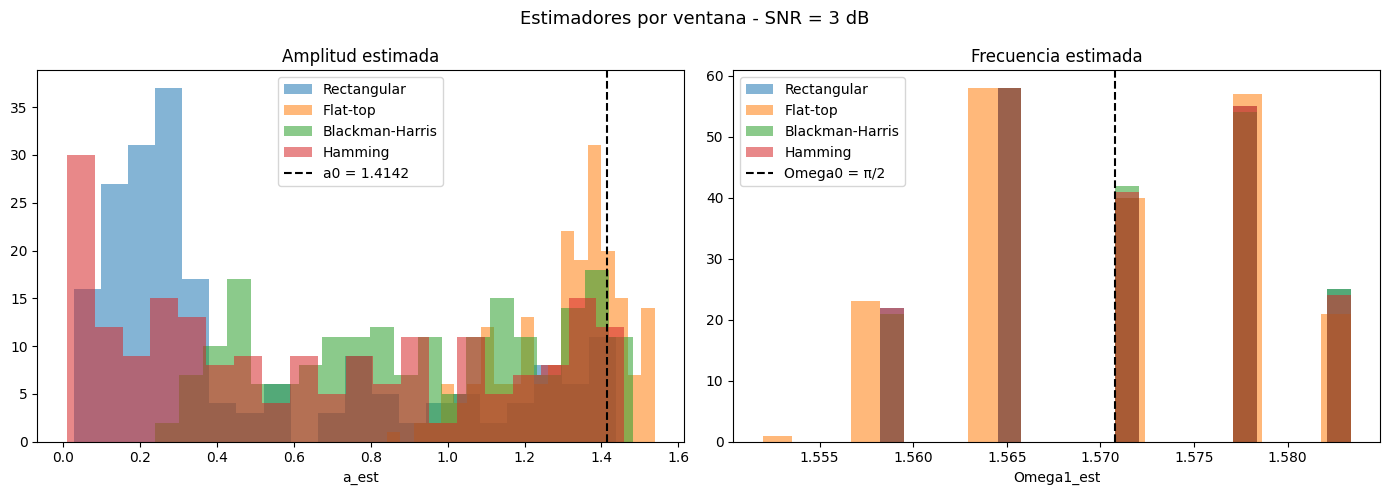

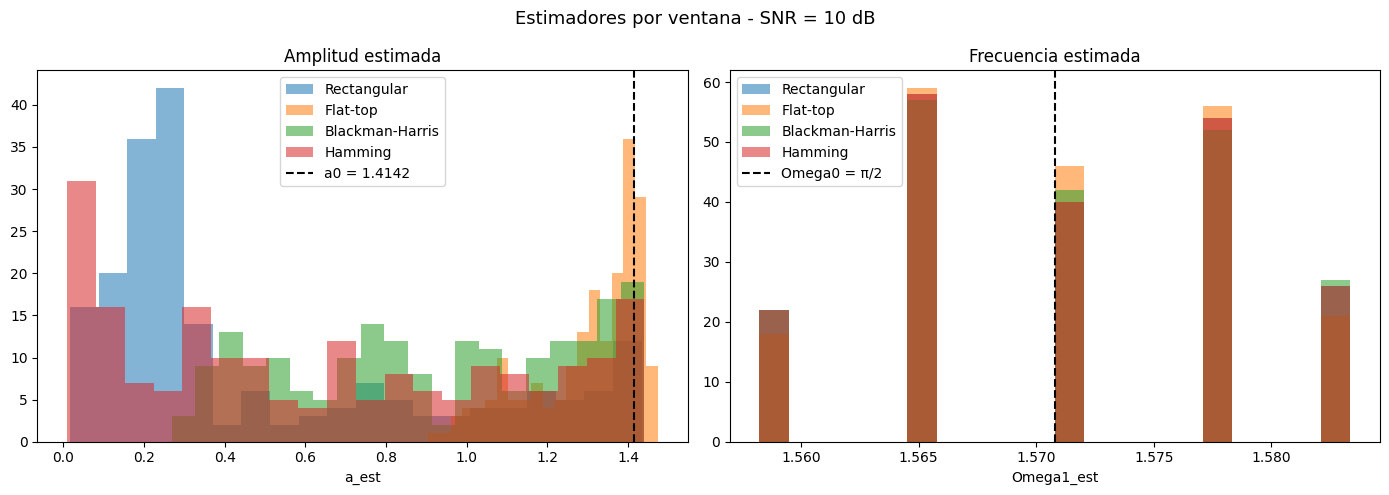

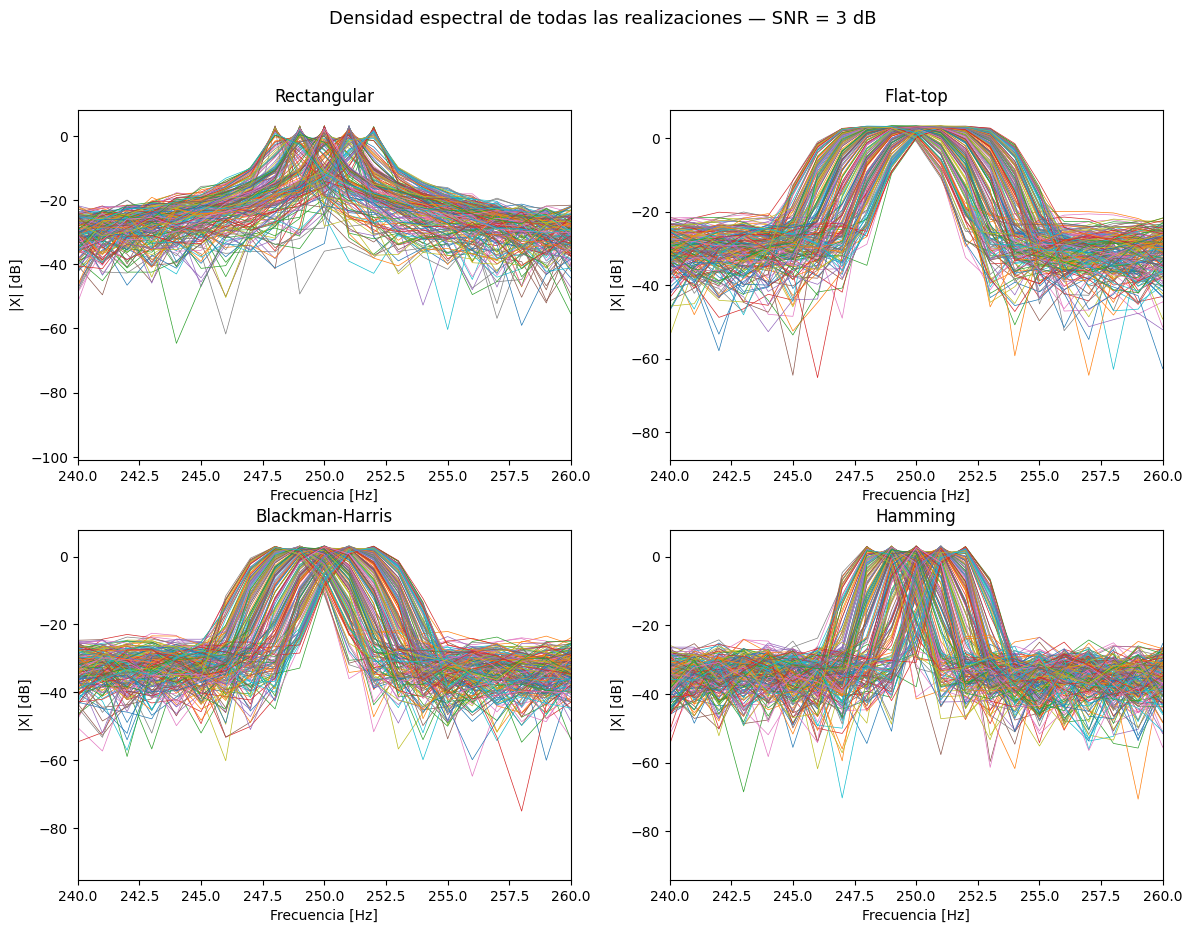

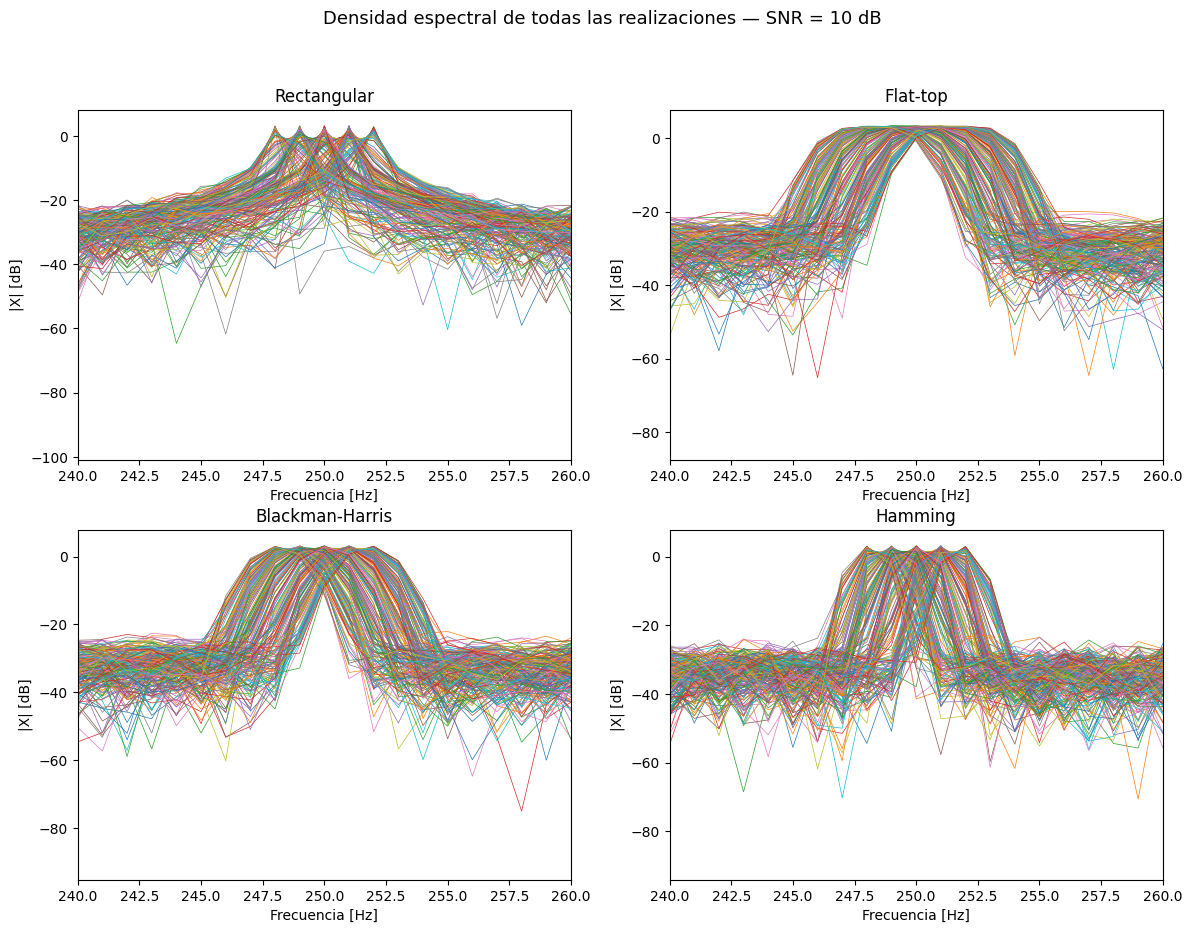

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal.windows as sci

# Agregar ruido AWGN
def agregar_ruido(x_s, snr_db):
    Ps     = np.mean(x_s**2, axis=0)
    sigma2 = Ps / (10**(snr_db / 10))
    return x_s + np.random.normal(0, np.sqrt(sigma2), x_s.shape)

# Parámetros
fs   = 1000
N    = fs
R    = 200           # realizaciones
a0   = np.sqrt(2)    # normalizada a 1W
k0 = N//4
Omega0 = 2*np.pi*k0/N  # π/2

ventanas = {
    "Rectangular": np.ones(N),
    "Flat-top": sci.flattop(N),
    "Blackman-Harris": sci.blackmanharris(N),
    "Hamming": sci.hamming(N),
}

fr = np.random.uniform(-2, 2, R).reshape(1,R)        # fr ~ U(-2, 2)
n = np.arange(N).reshape(N,1)
Omega1 = Omega0 + 2*np.pi*fr/N      # (1,R)

# R realizaciones de la señal sin ruido
x_s = a0 * np.sin(Omega1 * n) # (N, R)

# Estimación
resultados = {}

for snr_db in [3, 10]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Estimadores por ventana - SNR = {snr_db} dB", fontsize=13)

    x = agregar_ruido(x_s, snr_db)  # (N, R)

    for name, w in ventanas.items():
        X_w = np.fft.fft(x*w.reshape(N,1)/np.mean(w), axis=0) / N   # (N, R)
        X_abs = (np.abs(X_w)*2)[0:N//2, :]

        a_est = X_abs[k0, :]
        sesgo_a = np.mean(a_est) - a0
        var_a = np.var(a_est)

        Omega_est = 2*np.pi*np.argmax(X_abs, axis=0).reshape(1,R)/N
        sesgo_Omega = np.mean(Omega_est - Omega1)
        var_Omega = np.var(Omega_est - Omega1)

        resultados[(snr_db, name)] = (sesgo_a, var_a, sesgo_Omega, var_Omega)

        axes[0].hist(a_est, bins=20, alpha=0.55, label=name)
        axes[1].hist(Omega_est.reshape(R,1), bins=20, alpha=0.55, label=name)

    axes[0].axvline(a0, color='k', linestyle='--', label=f'a0 = {a0:.4f}')
    axes[0].set_title("Amplitud estimada")
    axes[0].set_xlabel("a_est")
    axes[0].legend()

    axes[1].axvline(Omega0, color='k', linestyle='--', label='Omega0 = π/2')
    axes[1].set_title("Frecuencia estimada")
    axes[1].set_xlabel("Omega1_est")
    axes[1].legend()

    plt.tight_layout()


#  Imprimir tablas
for snr_db in [3, 10]:
    print(f"\n{'='*68}")
    print(f"  SNR = {snr_db} dB   (R={R} realizaciones, N={N} muestras)")
    print(f"{'='*68}")

    print(f"\n  Estimación de AMPLITUD")
    print(f"  {'Ventana':<20} {'sa0 (sesgo)':<18} {'va0 (varianza)'}")
    print(f"  {'-'*55}")
    for name in ventanas:
        sa, va, _, _ = resultados[(snr_db, name)]
        print(f"  {name:<20} {sa:<18.6f} {va:.6f}")

    print(f"\n  Estimación de FRECUENCIA  (rad/muestra)")
    print(f"  {'Ventana':<20} {'sΩ (sesgo)':<18} {'vΩ (varianza)'}")
    print(f"  {'-'*55}")
    for name in ventanas:
        _, _, sf, vf = resultados[(snr_db, name)]
        print(f"  {name:<20} {sf:<18.2e} {vf:.2e}")


   # Densidades espectrales
    freqs = np.fft.rfftfreq(N, d=1/fs)   # eje de frecuencia en Hz
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Densidad espectral de todas las realizaciones — SNR = {snr_db} dB", fontsize=13)

    for ax, (name, w) in zip(axes.flatten(), ventanas.items()):
        X_w   = np.fft.rfft(x*w.reshape(N, 1) / np.mean(w), axis=0) / N   # (N//2+1, R)
        X_db  = 20 * np.log10(np.abs(X_w) * 2 + 1e-12)
        ax.plot(freqs, X_db, linewidth=0.5)
        ax.set_title(name)
        ax.set_xlabel("Frecuencia [Hz]")
        ax.set_ylabel("|X| [dB]")
        ax.set_xlim([fs/4 - 10, fs/4 + 10])


## Conclusiones

- El error en la estimación de amplitud resulta elevado debido a que el estimador toma el valor espectral exactamente en el bin correspondiente a Omega0 = π/2, mientras que la frecuencia real de la señal varía aleatoriamente entre realizaciones.

- Como consecuencia, gran parte de la energía de la señal se distribuye entre bins adyacentes debido al spectral leakage, generando un sesgo negativo importante en la estimación de amplitud.

- La ventana Flat-top presenta el menor sesgo y varianza en la estimación de amplitud. Esto puede observarse también en los histogramas, donde las estimaciones se concentran más alrededor del valor real a0. Este comportamiento es esperable ya que la ventana Flat-top está diseñada específicamente para mejorar la precisión en mediciones de amplitud espectral.

- La ventana rectangular presenta el peor desempeño en amplitud debido a sus elevados lóbulos laterales y mayor sensibilidad al desajuste frecuencial.

- La ventana Hamming presenta mayor dispersión en las estimaciones de amplitud, mientras que la Blackman-Harris muestra un comportamiento intermedio entre reducción de leakage y dispersión.

- En la estimación de frecuencia se observa que los resultados quedan cuantizados en valores discretos, debido a la resolución espectral limitada de la FFT.

- La diferencia entre SNR = 3 dB y SNR = 10 dB no produce cambios significativos en el sesgo ni en la varianza de los estimadores. Esto indica que el error está dominado principalmente por el leakage espectral y la resolución de frecuencia de la FFT, más que por el ruido agregado.


  SNR = 3 dB   (R=200 realizaciones, NFFT=1N muestras)

  Estimación de FRECUENCIA  (rad/muestra)
  Ventana              sΩ (sesgo)         vΩ (varianza)
  -------------------------------------------------------
  Rectangular          1.38e-04           3.29e-06
  Flat-top             -1.13e-04          7.40e-06
  Blackman-Harris      1.24e-05           3.36e-06
  Hamming              7.52e-05           3.30e-06

  SNR = 3 dB   (R=200 realizaciones, NFFT=2N muestras)

  Estimación de FRECUENCIA  (rad/muestra)
  Ventana              sΩ (sesgo)         vΩ (varianza)
  -------------------------------------------------------
  Rectangular          -3.47e-05          9.20e-07
  Flat-top             -1.90e-05          8.24e-06
  Blackman-Harris      -5.04e-05          9.48e-07
  Hamming              -1.90e-05          9.21e-07

  SNR = 3 dB   (R=200 realizaciones, NFFT=5N muestras)

  Estimación de FRECUENCIA  (rad/muestra)
  Ventana              sΩ (sesgo)         vΩ (varianza)
  ---------

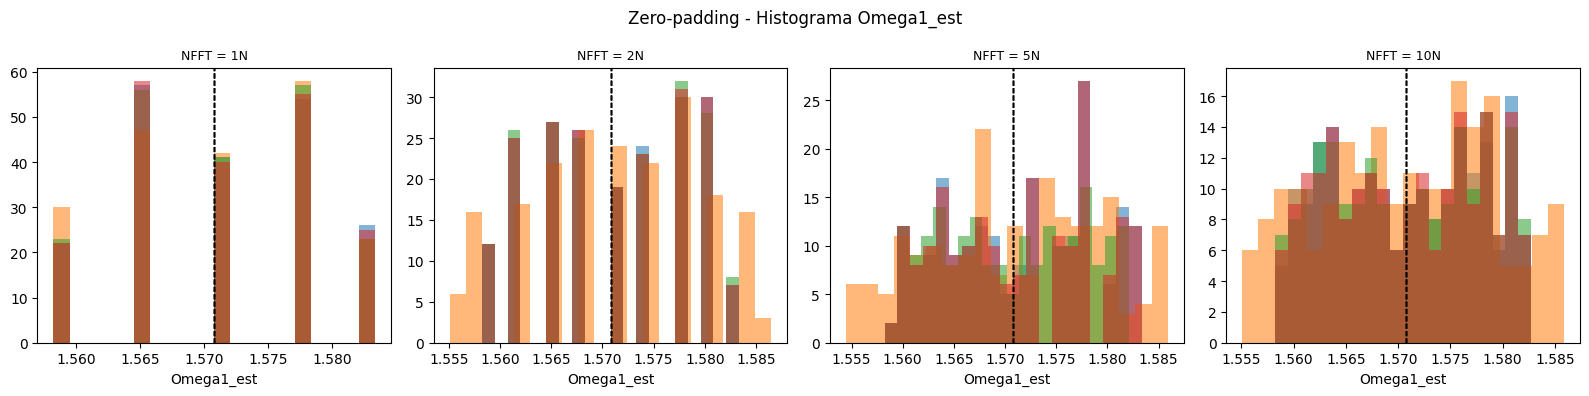

In [33]:
snr_db = 3
x = agregar_ruido(x_s, snr_db)

# Estimación
resultados = {}

NFFT_list = [N, 2*N, 5*N, 10*N]

fig, axes = plt.subplots(1, len(NFFT_list), figsize=(16, 4))
fig.suptitle("Zero-padding - Histograma Omega1_est")

for ax, NFFT in zip(axes, NFFT_list):
  for name, w in ventanas.items():
    X_w   = np.fft.fft(x*w.reshape(N,1)/np.mean(w), n=NFFT, axis=0) / N
    X_abs = (np.abs(X_w) * 2)[0:NFFT//2, :]

    Omega_est = 2 * np.pi * np.argmax(X_abs, axis=0).reshape(1, R) / NFFT

    sesgo_Omega = np.mean(Omega_est - Omega1)
    var_Omega   = np.var(Omega_est - Omega1)
    resultados[NFFT, name] = (sesgo_Omega, var_Omega)

    ax.hist(Omega_est.reshape(R,1), alpha=0.55, bins=20, label=name)
    ax.axvline(Omega0, color='k', linestyle='--', linewidth=1)
    ax.set_title(f"NFFT = {NFFT//N}N", fontsize=9)
    ax.set_xlabel("Omega1_est")

    plt.tight_layout()

  print(f"\n{'='*68}")
  print(f"  SNR = {snr_db} dB   (R={R} realizaciones, NFFT={NFFT//N}N muestras)")
  print(f"{'='*68}")

  print(f"\n  Estimación de FRECUENCIA  (rad/muestra)")
  print(f"  {'Ventana':<20} {'sΩ (sesgo)':<18} {'vΩ (varianza)'}")
  print(f"  {'-'*55}")
  for name in ventanas:
      sf, vf = resultados[NFFT, name]
      print(f"  {name:<20} {sf:<18.2e} {vf:.2e}")



## Conclusiones

- Al aumentar el tamaño de la FFT mediante zero padding se incrementa la densidad de muestras en frecuencia, permitiendo una estimación más fina de la ubicación del máximo espectral.

- Esto produce una mejora en la estimación de frecuencia, observable en la disminución del sesgo y la varianza del estimador de Omega.

- Los histogramas muestran que las estimaciones de frecuencia dejan de agruparse únicamente en unos pocos valores discretos y comienzan a distribuirse de forma más continua alrededor del valor real.

- El zero padding no agrega nueva información a la señal ni mejora la resolución espectral real, ya que la duración temporal de la señal permanece constante.

- Sin embargo, permite interpolar la FFT, facilitando la localización del máximo espectral y reduciendo el error de cuantización en frecuencia.

- En consecuencia, el zero padding mejora el desempeño práctico del estimador basado en argmax del módulo de la FFT, especialmente cuando la frecuencia de la señal no coincide exactamente con un bin de la FFT.